# Glint Data Processing Master Script

In this script each of the four versions of the glint experiment are able to be processed into a master data sheet for each experiment. 

The experiments include:
(1) Original Familiar Glint
(2) Original Novel Glint
In both of these experiments, three conditions of transformed images are presented with only one stimulus duration. 

The second set of experiments include: 
(3) Familiar Glint Extreme 
(4) Novel Glint Extreme
In these two versions, three conditions of transformed images are presented with 4 different stimulus durations. 

The distinction between familiar and novel is that familiar shows participants previously learned images, while novel presents unknown images that are learned and then tested on. 

The functions are split into two cells for the notebook for visualisation purposes, but for actual python script, they will grouped together at start of script.

I highly recommend always resetting the variables before each version.


In [4]:
#Clear previous output and variables to ensure no mixing of the data
%reset -f

# Import Necessary Packages 
import os
import pandas as pd
import glob
import numpy as np
import pdb

## Preprocessing and Exclusion Functions

In [ ]:
experiment = 'auto_bot' #version of the experiment: familiar or novel

#Need to differentiate the file paths based on if this is extreme or not
base = '/zpool/vladlab/data_drive/glint_master/data/adult_data' #base path for the data, this is the same for all versions of the experiment
#base = '/zpool/vladlab/data_drive/glint_data/' #base path for the data, this is the same for all versions of the experiment


core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path
print(f"You have selected {experiment} glint experiment")





#Now that they have selected the path for this version, it will gather all files associated with that version of the experiment    
files = glob.glob(f'{core_path}/*.csv')  
print(f"Example file path: {files[1]}") #print an example file path to confirm we are looking in the right place for the data files 

#adult_data/auto_bot_glint/054487_automobile_glint_2026-04-29_09h51.06.338.csv


You have selected auto_bot glint experiment
Example file path: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/286952_automobile_glint_2026-04-29_08h46.39.071.csv


In [34]:
def preprocessing_pipeline(experiment_type='auto_bot'):
    """Preprocess GLINT data based on experiment type and extreme flag.
    1. Sets experiment parameters.
    2. Loads data files.
    3. Loops through subjects, conditions, stimulus duration, and animacy to filter trials and calculate accuracy.
    4. Compiles results into a summary dataframe.
    
    Inputs: 
        experiment_type (str): 'novel' or 'familiar' to specify experiment version.
        is_extreme (bool): True for extreme version, False for original version.
    Returns:
        sub_summary (pd.DataFrame): Summary dataframe with accuracy and trial counts.
        settings (dict): Configuration dictionary with experiment parameters.
        experiment (str): Experiment version used.
        extreme (bool): Extreme flag used.
    """

    ''' Experiment parameters and settings (1 & 2 are inputs, 3-7 defined by the inputs or hard coded)
    1. experiment (novel or familiar)
    2. extreme flag (True for extreme version, False for original version)
    3. durations (if extreme is True) 
    4. animacies 
    5. base path for data
    6. file paths for the selected experiment version
    7. base columns for summary dataframe
    '''
    settings = {'experiment': experiment_type}
    
    experiment = settings['experiment'] #version of the experiment: familiar or novel
    
    animacy = 'inanim_artificial' #animacies for both versions of the experiment, but we define them here for clarity and consistency in the code structure


    # Define the columns for the summary dataframe, this will be used to compile the results for each subject and condition
    base_cols = ['experiment_label', 
                'id', #subject identifier
                'condition', #condition (natural, feature, shape)
                'stimulus_duration',#stimulus duration (only if extreme is True)
                'animacy', #animacy (only if animacy_inclusion is True)
                'practice_acc', #accuracy before filtering
                'filtered_acc', #accuracy after filtering
                'no_responses', #number of no responses
                'final_trial_count', #number of trials after all exclusions
                'number_of_outliers', #number of RT outliers
                'number_of_fast_responses', #number of fast responses (RT < 100ms)
                'number_of_excluded_trials'] #total number of excluded trials (no responses + fast responses + RT outliers)
    
    sub_summary = pd.DataFrame(columns=base_cols) #initialize empty dataframe with the appropriate columns, this will hold the final summary data

    #Need to differentiate the file paths based on if this is extreme or not
    base = '/zpool/vladlab/data_drive/glint_master/data/adult_data' #base path for the data, this is the same for all versions of the experiment
    #base = '/zpool/vladlab/data_drive/glint_data/' #base path for the data, this is the same for all versions of the experiment
    
 
    core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path
    print(f"You have selected {experiment} glint experiment")


    #Now that they have selected the path for this version, it will gather all files associated with that version of the experiment    
    files = glob.glob(f'{core_path}/*.csv')  
    print(f"Example file path: {files[1]}") #print an example file path to confirm we are looking in the right place for the data files 


    # Loop through each subject in this version of the experiment and process their data
    for file in files:
        print(f"\nProcessing file: {file}") #print the file being processed for tracking purposes
        try:
            predata = pd.read_csv(file) #read in the data file

        except Exception as e:
            print(f"Failed to read {file}: {e}")

            raise ValueError("No file by this name.")
        
    
        if 'participant' not in predata.columns:
            print(f"Error detected, 'participant' column missing in {file}")

            raise ValueError("Missing 'participant' column in data.") #Acts as a first layer defense to catch files that may not have the expected structure
        
        
        #Define a mapping of the data columns to standardize the column names across versions of the experiment 
        column_map = {
        "img_condition": "condition",
        "object_category": "animacy",
        "img_class": "test_object_class",
        "object_class": "test_object_class",}

        #rename the colimns to standardize across experiment versions
        data = predata.rename(columns=column_map)

        # Define a mapping for the conditions to standardize the condition names to their true names
        condition_mapping = {"natural": "natural", "scrambled": "feature", "line_drawing": "shape"}
        
        #Standardize the condition names in the data using the mapping
        data["condition"] = data["condition"].replace(condition_mapping)

        #get subject identifier from the data
        sub = data.loc[0, 'participant']
        print(f"\nProcessing Subject: {data.loc[0, 'participant']}")

        #initialize empty dataframe for this subject's conditions to hold the summary data for each loop through the conditions, stimulus durations, and animacies
        condition_summary = pd.DataFrame(columns=sub_summary.columns)
        
        # Check practice accuracy if column exists
        if 'prac_key_resp.corr' in data.columns:
            practice_trials = data['prac_key_resp.corr'].mean() #calculate practice trials accuracy
            #print(f"  Practice trials accuracy: {practice_trials:.3f}")
            if practice_trials < 0.5:
                print(f"  Caution: Low accuracy in practice trials for {data.loc[0, 'participant']} Accuracy =  {practice_trials:.3f}. Check data quality.")
            elif practice_trials >= 0.5:
                print(f"  Practice trials accuracy looks good for {data.loc[0, 'participant']}, Accuracy =  {practice_trials:.3f}")
        else:
            print(f"  Warning: 'prac_key_resp.corr' column not found in {file}")
        # Loop through each condition
        for condition in ['natural', 'feature', 'shape']:
            
            # Check for required columns
            needed = ['key_resp.corr', 'response_label','test_object_class','animacy','condition',]  #list of needed columns for processing

            if any(col not in data.columns for col in needed): 
                print(f"Missing expected columns in {file}") 
                raise ValueError("Missing expected columns in data.") #Second layer of defense to catch files that may be missing critical columns for the analysis
            
            
            # filter data by condition
            trials = data[(data['condition'] == condition)] #if not extreme, we don't need to filter by stimulus duration, so we only filter by condition and animacy

            # Check if trials is None or empty, and will raise an error if so
            if trials is None or len(trials) == 0:
                print(f"  No trials found for {condition}, {animacy}")
                raise ValueError("No trials found.")
            
            # Takes only trials with a response, and counts the number of no responses
            no_response_filter = trials[trials['response_label'] != 'no response'] #filter out no responses
            number_of_no_responses = len(trials) - len(no_response_filter) #count number of no responses


            '''
            Exclusion Criteria 1: RTs less than or equal to 100ms, and counts the number of fast responses
            Exclusion Criteria 2: RTs outside mean ± 2*SD
            We also remove no responses first, so that we are only looking at RTs for trials where there was a response, 
            and then we apply the RT filters to those trials. This way we can accurately count 
            the number of no responses, fast responses, and RT outliers separately.
            '''

            #Filters out RTs less than or equal to 100ms, and counts the number of fast responses
            rt_less_equal_100 = no_response_filter[no_response_filter['key_resp.rt'] >= 0.100] #filter out RTs less than or equal to 100ms
            number_of_fast_responses = len(no_response_filter) - len(rt_less_equal_100) #count number of RTs less than or equal to 100ms


            #Calculates the mean and standard deviation of RTs for trials with RTs greater than 100ms, which will be used to identify outliers based on the mean ± 2*SD criterion
            rt_plus_minus_2sd = rt_less_equal_100['key_resp.rt'].dropna() #drop NaN values
            mean_rt = rt_plus_minus_2sd.mean() #calculate mean RT
            std_rt = rt_plus_minus_2sd.std(ddof=1) #calculate standard deviation of RT



            #Filters out RTs outside mean ± 2*SD, and counts the number of RT outliers
            if len(rt_plus_minus_2sd) < 2 or pd.isna(std_rt): #if there are less than 2 trials with RTs greater than 100ms, we cannot calculate a standard deviation, so we will skip this step and not filter out any RTs based on the mean ± 2*SD criterion
                final_trials = rt_less_equal_100 #if we cannot calculate a standard deviation, we will not filter out any RTs based on the mean ± 2*SD criterion
            
            else:
                final_trials = rt_less_equal_100[rt_less_equal_100['key_resp.rt'].between(mean_rt - 2*std_rt, mean_rt + 2*std_rt)] #filter out RTs outside mean ± 2*SD

            number_of_outliers = len(rt_less_equal_100) - len(final_trials) #count number of RT outliers
                

            # Calculate the variables of interest and compile into a row for condition summary
            #acc = trials['key_resp.corr'].mean() #accuracy before filtering (removed from final code as it is meant for debugging)
            filtered_acc = final_trials['key_resp.corr'].mean() #accuracy after filtering   
            trial_count = len(final_trials) #number of trials after all exclusions


            #Combines the experiment and extreme parameters into a single label for the summary dataframe
            experiment_label = f"{experiment}_glint"  #combine experiment and extreme status into a single label for the summary dataframe    

            #sums up the total number of trials for this condition, stimulus duration, and animacy that were excluded based on the filters applied
            number_of_excluded_trials = number_of_no_responses + number_of_fast_responses + number_of_outliers 

            #Compiles all the variables of interest into a row for the condition summary dataframe
            row = {
                'experiment_label': experiment_label, #experiment and extreme status
                'id': sub, #subject identifier
                'condition': condition, #condition (natural, scrambled, line_drawing)
                'stimulus_duration': 0.3, #stimulus duration (only if extreme is True)
                'animacy': animacy, #animacy (only if animacy_inclusion is True)
                'practice_acc': practice_trials, #accuracy before filtering
                'filtered_acc': filtered_acc, #accuracy after filtering
                'no_responses': number_of_no_responses, #number of no responses
                'final_trial_count': trial_count, #number of trials after all exclusions
                'number_of_outliers': number_of_outliers, #number of RT outliers
                'number_of_fast_responses': number_of_fast_responses, #number of fast responses (RT < 100ms)
                'number_of_excluded_trials': number_of_excluded_trials, #total number of excluded trials
            }

            # Add the row to the condition summary
            condition_summary = pd.concat([condition_summary, pd.DataFrame([row])], ignore_index=True) #append the row to the condition summary

        # After processing all conditions for this subject, append to the overall sub_summary
        sub_summary = pd.concat([sub_summary, condition_summary], ignore_index=True) #append the condition summary to the overall sub_summary


    return sub_summary, experiment  # return config so downstream steps use the same values


'''
Exclusion Criteria Functions
Here we define the functions needed to do participant exclusion.
Our exclusion criteria are:
1. Participants with accuracy in the natural condition below chance level (calculated based on the number of response options for each experiment version).
2. Participants with accuracy in the natural condition below mean - 2*SD of the natural condition accuracies across all subjects.

Functions:
1. chance_calculator: Calculates the chance level based on the experiment version and extreme flag.
Inputs: experiment version (novel or familiar) and extreme flag (True or False)
Outputs: chance level (float)

2. exclusion_check: Identifies subjects to exclude based on the two criteria and prints the results
Inputs: sub_summary dataframe and chance level
Outputs: DataFrame of flagged subjects for exclusion

3. remove_flagged_subjects: Removes the flagged subjects from the sub_summary dataframe and returns the cleaned dataframe.
Inputs: sub_summary dataframe, flagged subjects dataframe, delete flag (True to remove, False to keep for review)
Outputs: cleaned sub_summary dataframe after removing flagged subjects (if delete=True), otherwise returns original sub_summary for review.

4. create_wide_format: Creates a wide-format version of the cleaned dataframe for downstream analyses.
Inputs: cleaned sub_summary dataframe
Outputs: cleaned long-format dataframe, cleaned wide-format dataframe, and saves both to CSV files with appropriate naming based on the experiment version and extreme flag.

5. plot_summary: Quick visualization function to plot the summary data for a quick check of the results after preprocessing.
'''
def chance_calculator(experiment, extreme):
    """Return the number of response options for the given experiment/extreme combo."""
    mapping = {
        ('novel', False): 4,
        ('novel', True): 4,
        ('familiar', True): 6,
        ('familiar', False): 9,
    }

    number_of_choices = mapping.get((experiment, extreme))

    chance = 1 / number_of_choices #formula for calculating chance 
    print(f"Calculated chance level based on {number_of_choices} choices: {chance:.3f}")
    return chance

def exclusion_check(sub_summary,chance):
    """Returns per_sub DataFrame with natural condition accuracies per subject."""
    
    natural_acc = sub_summary[sub_summary['condition'] == 'natural'] # Filters for the condition of natural, and calculates the mean
    
    if natural_acc.empty:
        print("No 'natural' rows found in `sub_summary`.")
        # Return empty DataFrame with expected columns to avoid UnboundLocalError
        raise ValueError("No 'natural' rows found in sub_summary; cannot compute exclusion criteria.")
    
    per_sub = (
        natural_acc.groupby('id', as_index=False)['filtered_acc']
        .mean()
        .rename(columns={'filtered_acc': 'natural_filtered_acc'})
    )

    """Calculate threshold for exclusion based on mean - 2*SD of natural accuracies."""
    mean_nat = per_sub['natural_filtered_acc'].mean() #calculate mean of natural filtered accuracy
    sd_nat = per_sub['natural_filtered_acc'].std(ddof=1) #calculate standard deviation of natural filtered accuracy
    thresh = mean_nat - 2 * sd_nat #calculate threshold as mean - 2*SD
    print(f"Natural condition: mean = {mean_nat:.3f}, sd = {sd_nat:.3f}, threshold (mean - 2sd) = {thresh:.3f}") #print threshold values
    
    ''' Flag subjects below chance level and below 2SD threshold, and print results.'''
    flagged_below_chance = per_sub[per_sub['natural_filtered_acc'] <= chance].copy() #flag subjects below chance level
    
    print(f"Chance threshold = {chance:.3f}") 
    
    print(f"Found {len(flagged_below_chance)} subject(s) below chance:") 
    
    if not flagged_below_chance.empty: 
        
        print(flagged_below_chance.sort_values('natural_filtered_acc')) #print flagged subjects below chance level
    

    flagged = per_sub[per_sub['natural_filtered_acc'] <= thresh].copy() #flag subjects below 2SD threshold
    
    print(f"Threshold for exclusion (mean - 2sd) = {thresh:.3f}")
    
    print(f"Found {len(flagged)} subject(s) below or equal to threshold:")
    
    if not flagged.empty:
        
        print(flagged.sort_values('natural_filtered_acc'))
    
    # Combine with flagged_below_chance if any
    if not flagged_below_chance.empty:
        
        flagged = pd.concat([flagged, flagged_below_chance], ignore_index=True).drop_duplicates()  #combine flagged subjects below chance with those below 2SD threshold
        
        print("Subjects below chance combined with subjects below 2SD threshold.")
    
    if flagged.empty:
        print("No subjects are below (or equal to) mean - 2*SD for natural filtered accuracy.")

    else:
        print(f"Flagged {len(flagged)} subject(s) total for exclusion:")

        print(flagged.sort_values('natural_filtered_acc'))
    
    return flagged 

def remove_flagged_subjects(sub_summary, flagged, delete=True):
    if flagged.empty:

        print("No subjects to remove based on exclusion criteria.")

        return sub_summary.copy() #return original sub_summary if no flagged subjects
    
    flagged_df = flagged.copy() #make a copy of flagged subjects DataFrame

    print(f"Flagged subjects to remove ({len(flagged_df)}):")

    print(flagged_df.sort_values('natural_filtered_acc'))
    
    flagged_subs = set(flagged_df['id']) #get unique subject identifiers from flagged subjects

    n_rows_before = len(sub_summary) #count number of rows before removal

    n_rows_removed = sub_summary['id'].isin(flagged_subs).sum() #count number of rows to be removed
    print(f"Preview: {n_rows_removed} rows (of {n_rows_before}) belong to flagged subject(s).") 
    
    if delete:

        cleaned = sub_summary[~sub_summary['id'].isin(flagged_subs)].copy() #remove flagged subjects from sub_summary
        print(f"Removed {n_rows_removed} rows.")
    else:
        cleaned = sub_summary.copy() #keep original sub_summary if delete is False
        print("Delete=False: Keeping all rows in cleaned dataset.")
    
    return cleaned


def create_wide_df_save(cleaned, experiment, output_path):
    cleaned_wide = None
    
    #I kept running into errors when trying to create the wide format, so I wrapped it in a try except block to catch any errors and print them out
    try:
        values = ['filtered_acc', 'practice_acc', 'no_responses', 'final_trial_count', 'number_of_outliers', 'number_of_fast_responses', 'number_of_excluded_trials'] #values to pivot on
        #values = ['un_filtered_acc', 'filtered_acc', 'no_responses', 'num_trials_after_exclusion', 'num_of_outliers', 'num_of_fast_responses', 'total_number_of_excluded_trials'] #values to pivot on

        pivot_df = cleaned.pivot(index='id', columns=['condition'], values=values) #pivot table with condition, stimulus_duration, and animacy as columns
        #pivot_df = cleaned.pivot(index='id', columns=['condition', 'stimulus_duration', 'animacy'], values=values) #pivot table with condition, stimulus_duration, and animacy as columns

        new_cols = [] #new column names list


        for col in pivot_df.columns: #loop through the columns in the pivoted dataframe to format the column names

            if len(col) == 3:
                metric, condition, duration = col #unpack the column tuple into metric, condition, and duration

                new_cols.append(f"{condition}_{duration}_{metric}") #format new column names

            else:
                new_cols.append("_".join([str(c) for c in col])) #join other columns as strings

        pivot_df.columns = new_cols #assign new column names to the pivoted dataframe

        pivot_df.reset_index(inplace=True) #reset index to make 'id' a column again

        cleaned_wide = pivot_df #assign pivoted DataFrame to cleaned_wide

        wide_df = cleaned_wide

        natural_cols = [c for c in wide_df.columns if c.startswith("filtered_acc_natural") and c != "filtered_acc_natural_overall"]
        feature_cols = [c for c in wide_df.columns if c.startswith("filtered_acc_feature") and c != "filtered_acc_feature_overall"]
        shape_cols   = [c for c in wide_df.columns if c.startswith("filtered_acc_shape")   and c != "filtered_acc_shape_overall"]

        natural_accuracy = wide_df[natural_cols].sum(axis=1, skipna=True) / len(natural_cols) if natural_cols else np.nan
        feature_accuracy = wide_df[feature_cols].sum(axis=1, skipna=True) / len(feature_cols) if feature_cols else np.nan
        shape_accuracy   = wide_df[shape_cols].sum(axis=1, skipna=True) / len(shape_cols) if shape_cols else np.nan

        wide_df["filtered_acc_natural_overall"] = natural_accuracy
        wide_df["filtered_acc_feature_overall"] = feature_accuracy
        wide_df["filtered_acc_shape_overall"]   = shape_accuracy

        cleaned_wide = wide_df
        
    except Exception as e:

        cleaned_wide = None #assign None to cleaned_wide if there was an error during pivoting

        print(f"Could not create wide-format: {e}") #alerts you if there was an error in pivoting data

    #Create a name for the final csv files based on the experiment version and extreme flag

    final_csv = f'{experiment}_glint_cleaned.csv' #construct final CSV filename

    #Save the cleaned long-format
    cleaned.to_csv(os.path.join(output_path, final_csv), index=False) #save long-format DataFrame to CSV

    print(f"Final cleaned sub_summary saved to {os.path.join(output_path, final_csv)}") 

    # Save the wide-format DataFrame to CSV, if it was successfully created
    if cleaned_wide is not None:

        

        cleaned_wide.to_csv(os.path.join(output_path, f'{experiment}_glint_cleaned_wide.csv'), index=False) #save wide-format DataFrame to CSV

        print(f"Final cleaned wide-format sub_summary saved to {os.path.join(output_path, f'{experiment}_glint_cleaned_wide.csv')}")

    return cleaned, cleaned_wide

# Quick Visualization
def plot_summary(data, extreme,chance):
    import seaborn as sns
    import matplotlib.pyplot as plt

    fig, ax1 = plt.subplots(figsize=(8, 5))
    if extreme == False:
        sns.barplot(
            data=data,
            x="condition",
            y="filtered_acc",
            ax = ax1,
            capsize=0.3,
            errorbar=("ci", 95),
            palette="magma",
            zorder=2,
            hue="condition"
        )
        sns.stripplot(
            data=data,
            x="condition",
            y="filtered_acc",
            ax = ax1,
            color='black',
            size=8,
            jitter=True,
            zorder=3,
            hue="condition",
            dodge=True
        )
    elif extreme == True:
        sns.pointplot(
            data=data,
            x="stimulus_duration",
            y="filtered_acc",
            hue="condition",
            palette="magma",
            order=[0.3, 0.136, 0.068, 0.034],
            capsize=0.2,
            errorbar= ("ci", 95)
        )
    
    ax1.set_ylim(0.1, 1.0)
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Condition')
    ax1.axhline(y=chance, color='black', linestyle='--', linewidth=1.5, zorder=11)
    return plt.gca()



In [38]:
def preprocessing_pipeline_img_version(experiment_type='auto_bot'):
    """Preprocess GLINT data based on experiment type and extreme flag.
    1. Sets experiment parameters.
    2. Loads data files.
    3. Loops through subjects, conditions, stimulus duration, and animacy to filter trials and calculate accuracy.
    4. Compiles results into a summary dataframe.
    
    Inputs: 
        experiment_type (str): 'novel' or 'familiar' to specify experiment version.
        is_extreme (bool): True for extreme version, False for original version.
    Returns:
        sub_summary (pd.DataFrame): Summary dataframe with accuracy and trial counts.
        settings (dict): Configuration dictionary with experiment parameters.
        experiment (str): Experiment version used.
        extreme (bool): Extreme flag used.
    """

    ''' Experiment parameters and settings (1 & 2 are inputs, 3-7 defined by the inputs or hard coded)
    1. experiment (novel or familiar)
    2. extreme flag (True for extreme version, False for original version)
    3. durations (if extreme is True) 
    4. animacies 
    5. base path for data
    6. file paths for the selected experiment version
    7. base columns for summary dataframe
    '''
    settings = {'experiment': experiment_type}
    
    experiment = settings['experiment'] #version of the experiment: familiar or novel
    
    animacy = 'inanim_artificial' #animacies for both versions of the experiment, but we define them here for clarity and consistency in the code structure

    test_object_classes = ['boat', 'car', 'bicycle', 'motorcycle'] #test object classes for both versions of the experiment, but we define them here for clarity and consistency in the code structure

    # Define the columns for the summary dataframe, this will be used to compile the results for each subject and condition
    base_cols = ['experiment_label', 
                'id', #subject identifier
                'condition', #condition (natural, feature, shape)
                'object_class', #test object class (boat, car, bicycle, motorcycle)
                'stimulus_duration',#stimulus duration (only if extreme is True)
                'animacy', #animacy (only if animacy_inclusion is True)
                'practice_acc', #accuracy before filtering
                'filtered_acc', #accuracy after filtering
                'no_responses', #number of no responses
                'final_trial_count', #number of trials after all exclusions
                'number_of_outliers', #number of RT outliers
                'number_of_fast_responses', #number of fast responses (RT < 100ms)
                'number_of_excluded_trials'] #total number of excluded trials (no responses + fast responses + RT outliers)
    
    sub_summary = pd.DataFrame(columns=base_cols) #initialize empty dataframe with the appropriate columns, this will hold the final summary data

    #Need to differentiate the file paths based on if this is extreme or not
    base = '/zpool/vladlab/data_drive/glint_master/data/adult_data' #base path for the data, this is the same for all versions of the experiment
    #base = '/zpool/vladlab/data_drive/glint_data/' #base path for the data, this is the same for all versions of the experiment
    
 
    core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path
    print(f"You have selected {experiment} glint experiment")


    #Now that they have selected the path for this version, it will gather all files associated with that version of the experiment    
    files = glob.glob(f'{core_path}/*.csv')  
    print(f"Example file path: {files[1]}") #print an example file path to confirm we are looking in the right place for the data files 


    # Loop through each subject in this version of the experiment and process their data
    for file in files:
        print(f"\nProcessing file: {file}") #print the file being processed for tracking purposes
        try:
            predata = pd.read_csv(file) #read in the data file

        except Exception as e:
            print(f"Failed to read {file}: {e}")

            raise ValueError("No file by this name.")
        
    
        if 'participant' not in predata.columns:
            print(f"Error detected, 'participant' column missing in {file}")

            raise ValueError("Missing 'participant' column in data.") #Acts as a first layer defense to catch files that may not have the expected structure
        
        
        #Define a mapping of the data columns to standardize the column names across versions of the experiment 
        column_map = {
        "img_condition": "condition",
        "object_category": "animacy",
        "img_class": "test_object_class",
        "object_class": "test_object_class",}

        #rename the colimns to standardize across experiment versions
        data = predata.rename(columns=column_map)

        # Define a mapping for the conditions to standardize the condition names to their true names
        condition_mapping = {"natural": "natural", "scrambled": "feature", "line_drawing": "shape"}
        
        #Standardize the condition names in the data using the mapping
        data["condition"] = data["condition"].replace(condition_mapping)

        #get subject identifier from the data
        sub = data.loc[0, 'participant']
        print(f"\nProcessing Subject: {data.loc[0, 'participant']}")

        #initialize empty dataframe for this subject's conditions to hold the summary data for each loop through the conditions, stimulus durations, and animacies
        condition_summary = pd.DataFrame(columns=sub_summary.columns)
        
        # Check practice accuracy if column exists
        if 'prac_key_resp.corr' in data.columns:
            practice_trials = data['prac_key_resp.corr'].mean() #calculate practice trials accuracy
            #print(f"  Practice trials accuracy: {practice_trials:.3f}")
            if practice_trials < 0.5:
                print(f"  Caution: Low accuracy in practice trials for {data.loc[0, 'participant']} Accuracy =  {practice_trials:.3f}. Check data quality.")
            elif practice_trials >= 0.5:
                print(f"  Practice trials accuracy looks good for {data.loc[0, 'participant']}, Accuracy =  {practice_trials:.3f}")
        else:
            print(f"  Warning: 'prac_key_resp.corr' column not found in {file}")
        # Loop through each condition
        for condition in ['natural', 'feature', 'shape']:
            for test_object_class in test_object_classes:
                    
                # Check for required columns
                needed = ['key_resp.corr', 'response_label','test_object_class','animacy','condition',]  #list of needed columns for processing

                if any(col not in data.columns for col in needed): 
                    print(f"Missing expected columns in {file}") 
                    raise ValueError("Missing expected columns in data.") #Second layer of defense to catch files that may be missing critical columns for the analysis
                
                
                # filter data by condition
                trials = data[(data['condition'] == condition) & (data['test_object_class'] == test_object_class)] #if not extreme, we don't need to filter by stimulus duration, so we only filter by condition and animacy

                # Check if trials is None or empty, and will raise an error if so
                if trials is None or len(trials) == 0:
                    print(f"  No trials found for {condition}, {test_object_class}")
                    raise ValueError("No trials found.")
                
                # Takes only trials with a response, and counts the number of no responses
                no_response_filter = trials[trials['response_label'] != 'no response'] #filter out no responses
                number_of_no_responses = len(trials) - len(no_response_filter) #count number of no responses


                '''
                Exclusion Criteria 1: RTs less than or equal to 100ms, and counts the number of fast responses
                Exclusion Criteria 2: RTs outside mean ± 2*SD
                We also remove no responses first, so that we are only looking at RTs for trials where there was a response, 
                and then we apply the RT filters to those trials. This way we can accurately count 
                the number of no responses, fast responses, and RT outliers separately.
                '''

                #Filters out RTs less than or equal to 100ms, and counts the number of fast responses
                rt_less_equal_100 = no_response_filter[no_response_filter['key_resp.rt'] >= 0.100] #filter out RTs less than or equal to 100ms
                number_of_fast_responses = len(no_response_filter) - len(rt_less_equal_100) #count number of RTs less than or equal to 100ms


                #Calculates the mean and standard deviation of RTs for trials with RTs greater than 100ms, which will be used to identify outliers based on the mean ± 2*SD criterion
                rt_plus_minus_2sd = rt_less_equal_100['key_resp.rt'].dropna() #drop NaN values
                mean_rt = rt_plus_minus_2sd.mean() #calculate mean RT
                std_rt = rt_plus_minus_2sd.std(ddof=1) #calculate standard deviation of RT



                #Filters out RTs outside mean ± 2*SD, and counts the number of RT outliers
                if len(rt_plus_minus_2sd) < 2 or pd.isna(std_rt): #if there are less than 2 trials with RTs greater than 100ms, we cannot calculate a standard deviation, so we will skip this step and not filter out any RTs based on the mean ± 2*SD criterion
                    final_trials = rt_less_equal_100 #if we cannot calculate a standard deviation, we will not filter out any RTs based on the mean ± 2*SD criterion
                
                else:
                    final_trials = rt_less_equal_100[rt_less_equal_100['key_resp.rt'].between(mean_rt - 2*std_rt, mean_rt + 2*std_rt)] #filter out RTs outside mean ± 2*SD

                number_of_outliers = len(rt_less_equal_100) - len(final_trials) #count number of RT outliers
                    

                # Calculate the variables of interest and compile into a row for condition summary
                #acc = trials['key_resp.corr'].mean() #accuracy before filtering (removed from final code as it is meant for debugging)
                filtered_acc = final_trials['key_resp.corr'].mean() #accuracy after filtering   
                trial_count = len(final_trials) #number of trials after all exclusions


                #Combines the experiment and extreme parameters into a single label for the summary dataframe
                experiment_label = f"{experiment}_glint"  #combine experiment and extreme status into a single label for the summary dataframe    

                #sums up the total number of trials for this condition, stimulus duration, and animacy that were excluded based on the filters applied
                number_of_excluded_trials = number_of_no_responses + number_of_fast_responses + number_of_outliers 

                #Compiles all the variables of interest into a row for the condition summary dataframe
                row = {
                    'experiment_label': experiment_label, #experiment and extreme status
                    'id': sub, #subject identifier
                    'condition': condition, #condition (natural, scrambled, line_drawing)
                    'object_class': test_object_class, #test object class (boat, car, bicycle, motorcycle)
                    'stimulus_duration': 0.3, #stimulus duration (only if extreme is True)
                    'animacy': animacy, #animacy (only if animacy_inclusion is True)
                    'practice_acc': practice_trials, #accuracy before filtering
                    'filtered_acc': filtered_acc, #accuracy after filtering
                    'no_responses': number_of_no_responses, #number of no responses
                    'final_trial_count': trial_count, #number of trials after all exclusions
                    'number_of_outliers': number_of_outliers, #number of RT outliers
                    'number_of_fast_responses': number_of_fast_responses, #number of fast responses (RT < 100ms)
                    'number_of_excluded_trials': number_of_excluded_trials, #total number of excluded trials
                }

                # Add the row to the condition summary
                condition_summary = pd.concat([condition_summary, pd.DataFrame([row])], ignore_index=True) #append the row to the condition summary

        # After processing all conditions for this subject, append to the overall sub_summary
        sub_summary = pd.concat([sub_summary, condition_summary], ignore_index=True) #append the condition summary to the overall sub_summary


    return sub_summary, experiment  # return config so downstream steps use the same values





# Run the Preprocessing and Exclusion Functions
Experiment 1: Familiar Original

Experiment 2: Familiar Extreme

Experiment 3: Novel Orginal

Experiment 4: Novel Extreme

## Autobot Glint

In [35]:
sub_summary, experiment = preprocessing_pipeline('auto_bot')

You have selected auto_bot glint experiment
Example file path: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/286952_automobile_glint_2026-04-29_08h46.39.071.csv

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/609475_automobile_glint_2026-04-29_06h49.43.212.csv

Processing Subject: 609475
  Practice trials accuracy looks good for 609475, Accuracy =  1.000

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/286952_automobile_glint_2026-04-29_08h46.39.071.csv

Processing Subject: 286952
  Practice trials accuracy looks good for 286952, Accuracy =  1.000

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/231705_automobile_glint_2026-04-29_09h59.45.054.csv

Processing Subject: 231705
  Practice trials accuracy looks good for 231705, Accuracy =  1.000

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/521984_automobile_g

In [39]:
sub_summary, experiment = preprocessing_pipeline_img_version('auto_bot')

stats = sub_summary.groupby('condition')['filtered_acc'].agg(['mean', 'std', 'count']).reset_index()
print(f'Pre-subject exclusion stats:\n{stats}')

sub_summary_removed_participants = sub_summary[~sub_summary['id'].isin([224158, 401568])]


stats = sub_summary_removed_participants.groupby('condition')['filtered_acc'].agg(['mean', 'std', 'count']).reset_index()

print(f'Post-subject exclusion stats:\n{stats}')

You have selected auto_bot glint experiment
Example file path: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/286952_automobile_glint_2026-04-29_08h46.39.071.csv

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/609475_automobile_glint_2026-04-29_06h49.43.212.csv

Processing Subject: 609475
  Practice trials accuracy looks good for 609475, Accuracy =  1.000

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/286952_automobile_glint_2026-04-29_08h46.39.071.csv

Processing Subject: 286952
  Practice trials accuracy looks good for 286952, Accuracy =  1.000

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/231705_automobile_glint_2026-04-29_09h59.45.054.csv

Processing Subject: 231705
  Practice trials accuracy looks good for 231705, Accuracy =  1.000

Processing file: /zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint/521984_automobile_g

/tmp/ipykernel_3641805/4082054094.py:20: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


<Axes: xlabel='object_class', ylabel='filtered_acc'>

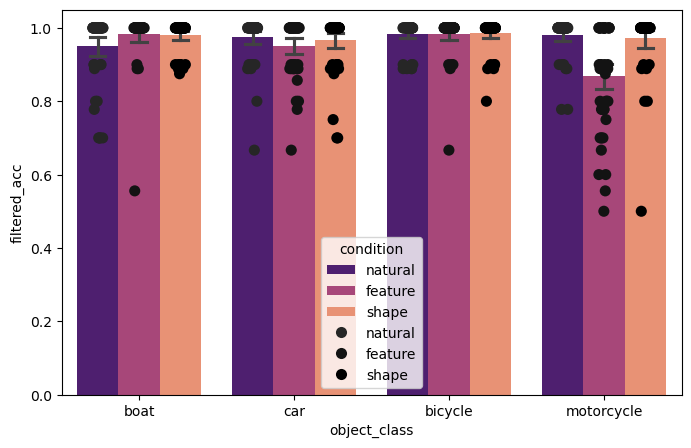

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# plot the summary data by object class to see how each object class looks across conditions
chance = 0.25

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.barplot(
        data=sub_summary_removed_participants,
        x="object_class",
        y="filtered_acc",
        ax = ax1,
        capsize=0.3,
        errorbar=("ci", 95),
        palette="magma",
        zorder=2,
        hue="condition"
    )
sns.stripplot(
        data=sub_summary_removed_participants,
        x="object_class",
        y="filtered_acc",
        ax = ax1,
        color='black',
        size=8,
        jitter=True,
        zorder=3,
        hue="condition",
        dodge=True
    )

In [ ]:
#Run the Exclusion Check, remove the flagged subjects, create the wide format, and save the cleaned dataframes to CSV files for the novel original version, experiment = 'novel' and extreme = False

#chance = chance_calculator(experiment, extreme= False) #Calculate chance level based on experiment version and extreme flag
#print(f"Running Exclusion check for experiment = {experiment}, chance level = {chance:.3f}")
chance = 0.25
flagged = exclusion_check(sub_summary,chance) #Flag subjects based on exclusion criteria

sub_summary_cleaned = remove_flagged_subjects(sub_summary, 
                                              flagged, 
                                              delete=True) # Remove flagged subjects

auto_bot_glint_long_df, auto_bot_glint_wide_df = create_wide_df_save(sub_summary_cleaned,
                                                                        experiment,
                                                                        output_path = '/zpool/vladlab/data_drive/glint_master/data/adult_data/summary_data_csv/') # Create wide format



plot_summary(auto_bot_glint_long_df, extreme=False, chance=chance)


Natural condition: mean = 0.974, sd = 0.033, threshold (mean - 2sd) = 0.909
Chance threshold = 0.250
Found 0 subject(s) below chance:
Threshold for exclusion (mean - 2sd) = 0.909
Found 2 subject(s) below or equal to threshold:
        id  natural_filtered_acc
11  224158              0.868421
19  401568              0.894737
Flagged 2 subject(s) total for exclusion:
        id  natural_filtered_acc
11  224158              0.868421
19  401568              0.894737
Flagged subjects to remove (2):
        id  natural_filtered_acc
11  224158              0.868421
19  401568              0.894737
Preview: 6 rows (of 150) belong to flagged subject(s).
Removed 6 rows.


NameError: name 'auto_bot_glint_long_df' is not defined

# Check each object class performance and response

In [13]:
import glob
import pandas as pd

# Get all participant files from auto_bot_glint
base = '/zpool/vladlab/data_drive/glint_master/data/adult_data/auto_bot_glint'
files = glob.glob(f'{base}/*.csv')

motorcycle_summary = []
boat_summary = []
car_summary = []
bicycle_summary = []

for objects in ['motorcycle', 'boat', 'car', 'bicycle']:
    for file in files:
        data = pd.read_csv(file)
        
        # Filter for the current object class
        object_trials = data[data['img_class'] == objects]
        
        if len(object_trials) > 0:
            # Extract only the columns you want
            subset = object_trials[['response_label', 'key_resp.corr', 'key_resp.keys', 'condition', 'img_class']].copy()
            
            # Add participant ID for reference
            subset['participant'] = data.loc[0, 'participant']
            
            # Append to the appropriate summary list
            if objects == 'motorcycle':
                motorcycle_summary.append(subset)
            elif objects == 'boat':
                boat_summary.append(subset)
            elif objects == 'car':
                car_summary.append(subset)
            elif objects == 'bicycle':
                bicycle_summary.append(subset)

    # Combine all into one dataframe
    if objects == 'motorcycle':
        motorcycle_df = pd.concat(motorcycle_summary, ignore_index=True)
    elif objects == 'boat':
        boat_df = pd.concat(boat_summary, ignore_index=True)
    elif objects == 'car':
        car_df = pd.concat(car_summary, ignore_index=True)
    elif objects == 'bicycle':
        bicycle_df = pd.concat(bicycle_summary, ignore_index=True)

    # Reorder columns with participant first
    if objects == 'motorcycle':
        motorcycle_df = motorcycle_df[['participant', 'response_label', 'key_resp.corr', 'key_resp.keys', 'condition', 'img_class']]

    elif objects == 'boat':
        boat_df = boat_df[['participant', 'response_label', 'key_resp.corr', 'key_resp.keys', 'condition', 'img_class']]
    elif objects == 'car':
        car_df = car_df[['participant', 'response_label', 'key_resp.corr', 'key_resp.keys', 'condition', 'img_class']]
    elif objects == 'bicycle':
        bicycle_df = bicycle_df[['participant', 'response_label', 'key_resp.corr', 'key_resp.keys', 'condition', 'img_class']]
    print(f"Total {objects} trials: {len(motorcycle_df)}")
    print(f"Participants with {objects} trials: {motorcycle_df['participant'].nunique()}")
    print("\n", motorcycle_df.head(10))

Total motorcycle trials: 1500
Participants with motorcycle trials: 50

    participant response_label  key_resp.corr  key_resp.keys  condition  \
0       609475     motorcycle            1.0            3.0  scrambled   
1       609475     motorcycle            1.0            3.0  scrambled   
2       609475     motorcycle            1.0            3.0  scrambled   
3       609475     motorcycle            1.0            3.0  scrambled   
4       609475     motorcycle            1.0            3.0  scrambled   
5       609475     motorcycle            1.0            3.0  scrambled   
6       609475     motorcycle            1.0            3.0  scrambled   
7       609475     motorcycle            1.0            3.0  scrambled   
8       609475        bicycle            0.0            2.0  scrambled   
9       609475     motorcycle            1.0            3.0  scrambled   

    img_class  
0  motorcycle  
1  motorcycle  
2  motorcycle  
3  motorcycle  
4  motorcycle  
5  motorcycle  
6

In [14]:
# Now, read through each df and print out the counts of the top 4 most common response labels for each object class
for df, name in zip([motorcycle_df, boat_df, car_df, bicycle_df], ['motorcycle', 'boat', 'car', 'bicycle']):
    print(f"\n{name.upper()} RESPONSE LABEL COUNTS:")
    print(df['response_label'].value_counts().head(4))


MOTORCYCLE RESPONSE LABEL COUNTS:
response_label
motorcycle    1392
bicycle         59
car             40
boat             6
Name: count, dtype: int64

BOAT RESPONSE LABEL COUNTS:
response_label
boat          1439
car             30
bicycle         14
motorcycle      13
Name: count, dtype: int64

CAR RESPONSE LABEL COUNTS:
response_label
car           1434
boat            27
motorcycle      22
bicycle         10
Name: count, dtype: int64

BICYCLE RESPONSE LABEL COUNTS:
response_label
bicycle       1464
motorcycle      16
boat            11
car              7
Name: count, dtype: int64
